# Task B — Interpretability Comparison: Dry Bean Dataset

This notebook compares four feature-importance methods on the **Dry Bean** dataset (7-class, 16 numerical features):

| Method | Type | What it measures |
|--------|------|-------------------|
| **AGOP Diagonal** | Supervised, model-internal | Gradient-sensitivity of xRFM at each input coordinate |
| **PCA Loadings** | Unsupervised | Direction of maximum input variance (ignores labels) |
| **Mutual Information** | Supervised, univariate | Statistical dependence between each feature and the target |
| **Permutation Importance** | Supervised, model-external | Drop in xRFM accuracy when a feature is randomly shuffled |

The key spec requirement: extract the AGOP diagonal **from each xRFM leaf** separately, then aggregate via a **sample-count-weighted average** across leaves.

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid', font_scale=1.2)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT_DIR   = os.path.dirname(os.getcwd())
DATA_DIR   = os.path.join(ROOT_DIR, 'data', 'dry_bean')
MODEL_DIR  = os.path.join(ROOT_DIR, 'saved_models', 'dry_bean')
RESULT_DIR = os.path.join(ROOT_DIR, 'results')
os.makedirs(RESULT_DIR, exist_ok=True)

print('Root:', ROOT_DIR)
print('Data:', DATA_DIR)
print('Models:', MODEL_DIR)

Root: /home/wuxinzhe76/COMP9417-PR
Data: /home/wuxinzhe76/COMP9417-PR/data/dry_bean
Models: /home/wuxinzhe76/COMP9417-PR/saved_models/dry_bean


## 1. Load Data and Preprocessor

In [2]:
def load_split(split):
    base = os.path.join(DATA_DIR, split)
    X = pd.read_csv(os.path.join(base, 'X.csv'))
    y = pd.read_csv(os.path.join(base, 'y.csv')).iloc[:, 0]
    return X, y

X_train_raw, y_train_raw = load_split('train')
X_val_raw,   y_val_raw   = load_split('val')
X_test_raw,  y_test_raw  = load_split('test')

FEATURE_NAMES = list(X_train_raw.columns)
print(f'Feature names ({len(FEATURE_NAMES)}): {FEATURE_NAMES}')
print(f'Train / Val / Test: {len(X_train_raw)} / {len(X_val_raw)} / {len(X_test_raw)}')

Feature names (16): ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']
Train / Val / Test: 8166 / 2722 / 2723


In [3]:
# Load the preprocessor (StandardScaler fitted on train only) and LabelEncoder.
meta = joblib.load(os.path.join(MODEL_DIR, 'preprocessor.pkl'))
le   = joblib.load(os.path.join(MODEL_DIR, 'label_encoder.pkl'))

scaler   = meta['scaler']
num_cols = meta['num_cols']  # all 16 features (no categorical in Dry Bean)

# Apply the same scaler that was used during training — NO re-fitting.
X_train_np = scaler.transform(X_train_raw[num_cols]).astype(np.float32)
X_val_np   = scaler.transform(X_val_raw[num_cols]).astype(np.float32)
X_test_np  = scaler.transform(X_test_raw[num_cols]).astype(np.float32)

# Encode string labels to int 0-6.
y_train_enc = le.transform(y_train_raw)
y_val_enc   = le.transform(y_val_raw)
y_test_enc  = le.transform(y_test_raw)

print('Classes:', list(le.classes_))
print('X_train_np shape:', X_train_np.shape)
print('Scaler mean (first 4):', scaler.mean_[:4].round(2))

Classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
X_train_np shape: (8166, 16)
Scaler mean (first 4): [53011.31   854.9    319.87   202.34]


## 2. Load the Trained xRFM Model

In [4]:
xrfm_model = joblib.load(os.path.join(MODEL_DIR, 'xrfm.pkl'))
print('xRFM loaded.')
print(f'  n_trees = {xrfm_model.n_trees}')

# Verify we have at least one tree.
assert xrfm_model.trees is not None and len(xrfm_model.trees) > 0

# Report the tree structure (splits vs single leaf).
for t_idx, tree in enumerate(xrfm_model.trees):
    leaves = xrfm_model._collect_leaf_nodes(tree)
    total_splits = sum(1 for l in leaves) - 1  # rough proxy
    print(f'  Tree {t_idx}: {len(leaves)} leaf node(s)')

xRFM loaded.
  n_trees = 1
  Tree 0: 4 leaf node(s)


## 3. Per-Leaf AGOP Extraction (Weighted Average)

**Theory recap**: AGOP for a model $f$ is $\text{AGOP}(f) = \frac{1}{n}\sum_{i=1}^{n} \nabla f(x_i)\nabla f(x_i)^\top$.
In RFM, this is captured by the learned Mahalanobis matrix `model.M` — a $d\times d$ matrix whose
diagonal entries measure coordinate-wise gradient sensitivity.

**Per-leaf aggregation strategy**: Each leaf $\ell$ owns $n_\ell$ training samples (stored in
`leaf_node['train_indices']`). Its local AGOP (`leaf_model.M`) is only representative of that
data region. A correct global estimate weights each leaf's AGOP by its sample fraction:
$$\text{AGOP}_{\text{global}} = \sum_{\ell} \frac{n_\ell}{n_{\text{train}}} \cdot M_\ell$$
This is equivalent to the population-level AGOP if leaves partition the input space.

In [5]:
def extract_weighted_agop_diagonal(model, feature_names):
    """
    Compute a sample-count-weighted average of the AGOP diagonal across
    all leaf nodes in all trees of a fitted xRFM model.

    Each leaf's AGOP is stored in leaf_model.M (the Mahalanobis matrix
    learned by the leaf-level RFM). Its diagonal entries are the
    coordinate-wise gradient sensitivities for samples in that leaf's
    data region.

    Weight = n_leaf / n_total_train, so that larger leaves contribute
    proportionally more to the global importance estimate.

    Parameters
    ----------
    model : fitted xRFM instance
    feature_names : list of str

    Returns
    -------
    pd.Series  indexed by feature_names, values = weighted-avg AGOP diagonal
    """
    d = len(feature_names)

    # Accumulate: weighted_M_sum[j] = sum_l ( n_l * M_l[j,j] )
    weighted_diag_sum = np.zeros(d, dtype=np.float64)
    total_n = 0

    leaf_report = []

    for tree_idx, tree in enumerate(model.trees):
        leaf_nodes = model._collect_leaf_nodes(tree)

        for leaf in leaf_nodes:
            leaf_model = leaf['model']

            # n_leaf: number of training samples that landed in this leaf.
            # train_indices is a LongTensor of shape (n_leaf,).
            n_leaf = int(leaf['train_indices'].numel())

            # leaf_model.M is the learned Mahalanobis matrix (= AGOP after
            # the RFM iterations). Shape: (d, d) when diag=False.
            # If M is None (can happen if the model converged before the
            # first AGOP update), fall back to the identity — neutral weight.
            M = leaf_model.M
            if M is None:
                leaf_diag = np.ones(d, dtype=np.float64)
                note = 'M=None → identity fallback'
            else:
                M_np = M.detach().cpu().numpy()
                if M_np.ndim == 1:
                    # Diagonal-mode RFM (diag=True); M IS the diagonal.
                    leaf_diag = M_np.astype(np.float64)
                else:
                    # Full matrix: extract the main diagonal.
                    leaf_diag = np.diag(M_np).astype(np.float64)
                note = f'shape={M_np.shape}'

            # Accumulate weighted diagonal.
            weighted_diag_sum += n_leaf * leaf_diag
            total_n += n_leaf

            leaf_report.append({
                'tree': tree_idx,
                'n_leaf': n_leaf,
                'weight': None,  # filled below
                'M_note': note,
                'top_feature': feature_names[np.argmax(leaf_diag)],
            })

    # Normalise by total sample count.
    agop_diag_weighted = weighted_diag_sum / total_n

    # Fill per-leaf weight for the report.
    cumulative = 0
    for row in leaf_report:
        row['weight'] = row['n_leaf'] / total_n

    df_report = pd.DataFrame(leaf_report)
    print('=== Per-leaf AGOP extraction report ===')
    print(df_report.to_string(index=False))
    print(f'\nTotal samples accounted for: {total_n}')

    return pd.Series(agop_diag_weighted, index=feature_names, name='AGOP')


agop_scores = extract_weighted_agop_diagonal(xrfm_model, FEATURE_NAMES)
print('\nRaw AGOP diagonal (weighted):')
print(agop_scores.sort_values(ascending=False))

=== Per-leaf AGOP extraction report ===
 tree  n_leaf  weight         M_note top_feature
    0    2352    0.25 shape=(16, 16)   Roundness
    0    2352    0.25 shape=(16, 16)   Roundness
    0    2352    0.25 shape=(16, 16)   Roundness
    0    2352    0.25 shape=(16, 16)   Roundness

Total samples accounted for: 9408

Raw AGOP diagonal (weighted):
Roundness          1.000000
ShapeFactor4       0.539446
ShapeFactor1       0.534758
Solidity           0.342024
MinorAxisLength    0.329744
Perimeter          0.304420
EquivDiameter      0.234784
Extent             0.202781
ConvexArea         0.156219
Area               0.154880
MajorAxisLength    0.134453
AspectRatio        0.094454
Compactness        0.084595
ShapeFactor3       0.079180
ShapeFactor2       0.066904
Eccentricity       0.056076
Name: AGOP, dtype: float64


## 4. PCA Loadings (First Principal Component)

PCA finds the direction of **maximum input variance**, ignoring labels entirely.
The absolute values of the first-PC loading vector serve as unsupervised feature
importance scores.  Because StandardScaler has already been applied, PCA is fit
on the whitened training data.

In [6]:
# PCA is fit on the ALREADY-SCALED training data (no second scaler needed).
pca = PCA(n_components=len(FEATURE_NAMES), random_state=RANDOM_STATE)
pca.fit(X_train_np)

# First PC loading vector (absolute value = directional importance).
# components_[0] has shape (d,) — the first principal component.
pca_loadings = np.abs(pca.components_[0])
pca_scores   = pd.Series(pca_loadings, index=FEATURE_NAMES, name='PCA (PC1 loadings)')

print(f'PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance')
print(f'PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance')
print('\nPCA loadings (sorted):')
print(pca_scores.sort_values(ascending=False))

PC1 explains 55.4% of variance
PC2 explains 26.4% of variance

PCA loadings (sorted):


MajorAxisLength    0.325852
ShapeFactor2       0.314927
Perimeter          0.310826
EquivDiameter      0.297397
ConvexArea         0.283050
Area               0.282278
Roundness          0.248594
ShapeFactor3       0.239164
Compactness        0.238527
MinorAxisLength    0.236045
Eccentricity       0.231931
AspectRatio        0.229399
ShapeFactor1       0.221515
ShapeFactor4       0.195462
Solidity           0.142697
Extent             0.064205
Name: PCA (PC1 loadings), dtype: float32


## 5. Mutual Information

Mutual information measures the **univariate statistical dependence** between each
feature and the (integer-encoded) class label, without fitting any model.

In [7]:
mi_values = mutual_info_classif(
    X_train_np, y_train_enc, discrete_features=False, random_state=RANDOM_STATE
)
mi_scores = pd.Series(mi_values, index=FEATURE_NAMES, name='Mutual Information')

print('Mutual Information scores (sorted):')
print(mi_scores.sort_values(ascending=False))

Mutual Information scores (sorted):
Perimeter          1.050943
ConvexArea         1.039002
EquivDiameter      1.031657
Area               1.031464
MajorAxisLength    0.979278
MinorAxisLength    0.938823
ShapeFactor2       0.937106
ShapeFactor1       0.934747
ShapeFactor3       0.815746
Compactness        0.815734
Eccentricity       0.802491
AspectRatio        0.802486
Roundness          0.796307
ShapeFactor4       0.365255
Solidity           0.241617
Extent             0.191560
Name: Mutual Information, dtype: float64


## 6. Permutation Importance (on xRFM, Test Set)

Permutation importance is a **model-external** post-hoc method: each feature is
randomly shuffled one at a time and the resulting drop in predictive accuracy is
recorded.  Using the **same xRFM model** keeps the comparison fair — AGOP (internal)
vs PI (external) both describe the *same* function.

In [8]:
# ---------------------------------------------------------------------------
# xRFM was trained with y passed as float32, so internally it solves a
# *regression* problem on integer labels 0–6 and returns predictions with
# shape (n, 1).  We decode class predictions by squeezing and rounding.
#
# sklearn's permutation_importance requires an estimator with a `fit` method,
# which xRFM does not expose in a sklearn-compatible way.  We therefore
# implement a manual permutation importance loop that is equivalent but
# avoids the sklearn interface entirely.
# ---------------------------------------------------------------------------

def xrfm_predict_classes(X, model=xrfm_model, n_classes=7):
    """
    Decode xRFM continuous output to integer class labels.
    xRFM regression on integer labels outputs shape (n, 1);
    squeeze to (n,), round, and clip to valid class range.
    """
    y_cont = model.predict(X)          # shape (n, 1)
    return np.round(y_cont.squeeze()).clip(0, n_classes - 1).astype(int)


def manual_permutation_importance(predict_fn, X, y_true, n_repeats=10, random_state=42):
    """
    Compute permutation importance without sklearn's estimator interface.

    For each feature j:
      - Shuffle column j in X, measure accuracy drop vs baseline.
      - Repeat n_repeats times; return mean drop across repeats.

    A large positive value means the model relies heavily on that feature.
    Negative values (feature removal accidentally helps) are clipped to 0.
    """
    rng           = np.random.RandomState(random_state)
    baseline_acc  = accuracy_score(y_true, predict_fn(X))
    n_features    = X.shape[1]
    drop_matrix   = np.zeros((n_features, n_repeats))

    for j in range(n_features):
        for r in range(n_repeats):
            X_perm         = X.copy()
            X_perm[:, j]   = rng.permutation(X_perm[:, j])
            perm_acc       = accuracy_score(y_true, predict_fn(X_perm))
            drop_matrix[j, r] = baseline_acc - perm_acc  # positive = important

    return drop_matrix.mean(axis=1)  # shape (n_features,)


# Sanity check before the loop.
baseline_acc = accuracy_score(y_test_enc, xrfm_predict_classes(X_test_np))
print(f'Baseline xRFM test accuracy (rounded predictions): {baseline_acc:.4f}')

print(f'Computing permutation importance ({len(FEATURE_NAMES)} features × 10 repeats) …')
pi_mean = manual_permutation_importance(
    predict_fn   = xrfm_predict_classes,
    X            = X_test_np,
    y_true       = y_test_enc,
    n_repeats    = 10,
    random_state = RANDOM_STATE,
)

# Clip negatives to 0: shuffling a weakly-correlated feature can randomly
# improve accuracy due to noise — treat these as zero importance.
pi_mean   = np.clip(pi_mean, 0, None)
pi_scores = pd.Series(pi_mean, index=FEATURE_NAMES, name='Permutation Importance')

print('\nPermutation Importance scores (sorted):')
print(pi_scores.sort_values(ascending=False))

Using soft routing for tree prediction
Baseline xRFM test accuracy (rounded predictions): 0.8358
Computing permutation importance (16 features × 10 repeats) …
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction


Using soft routing for tree prediction


Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction


Using soft routing for tree prediction


Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction


...

Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction


Using soft routing for tree prediction


Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction


Using soft routing for tree prediction


Using soft routing for tree prediction

Permutation Importance scores (sorted):
Roundness          0.191003
ShapeFactor4       0.122806
ShapeFactor1       0.113184
Solidity           0.066985
ShapeFactor3       0.056078
Compactness        0.055307
AspectRatio        0.053287
Perimeter          0.047888
MinorAxisLength    0.047631
Eccentricity       0.043702
EquivDiameter      0.031032
MajorAxisLength    0.023357
ConvexArea         0.020015
ShapeFactor2       0.019390
Extent             0.018582
Area               0.018289
Name: Permutation Importance, dtype: float64


## 7. Normalise All Scores to [0, 1]

Min-max normalisation allows visual comparison on a common scale.
Rankings — not absolute magnitudes — are what matter here.

In [9]:
def minmax_norm(s):
    """Normalise a pd.Series to [0, 1]."""
    lo, hi = s.min(), s.max()
    if hi - lo < 1e-12:
        return s * 0.0  # degenerate: all zeros
    return (s - lo) / (hi - lo)


agop_norm = minmax_norm(agop_scores).rename('AGOP')
pca_norm  = minmax_norm(pca_scores ).rename('PCA')
mi_norm   = minmax_norm(mi_scores  ).rename('Mutual Information')
pi_norm   = minmax_norm(pi_scores  ).rename('Permutation Importance')

# Master DataFrame: features as rows, methods as columns.
df_importance = pd.concat([agop_norm, pca_norm, mi_norm, pi_norm], axis=1)

# Sort features by AGOP score (descending) — this is the primary ordering.
df_importance = df_importance.sort_values('AGOP', ascending=False)

print('Normalised importances (sorted by AGOP):')
print(df_importance.round(3).to_string())

Normalised importances (sorted by AGOP):
                  AGOP    PCA  Mutual Information  Permutation Importance
Roundness        1.000  0.705               0.704                   1.000
ShapeFactor4     0.512  0.502               0.202                   0.605
ShapeFactor1     0.507  0.601               0.865                   0.549
Solidity         0.303  0.300               0.058                   0.282
MinorAxisLength  0.290  0.657               0.870                   0.170
Perimeter        0.263  0.943               1.000                   0.171
EquivDiameter    0.189  0.891               0.978                   0.074
Extent           0.155  0.000               0.000                   0.002
ConvexArea       0.106  0.836               0.986                   0.010
Area             0.105  0.833               0.977                   0.000
MajorAxisLength  0.083  1.000               0.917                   0.029
AspectRatio      0.041  0.631               0.711                   0.2

## 8. Rank Correlation Analysis

Spearman rank correlations quantify agreement between methods *before* we visualise.

In [10]:
methods = ['AGOP', 'PCA', 'Mutual Information', 'Permutation Importance']
corr_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float)

for m1 in methods:
    for m2 in methods:
        rho, _ = spearmanr(df_importance[m1], df_importance[m2])
        corr_matrix.loc[m1, m2] = round(rho, 3)

print('Spearman rank correlations between feature-importance methods:')
print(corr_matrix.to_string())

Spearman rank correlations between feature-importance methods:
                         AGOP    PCA  Mutual Information  Permutation Importance
AGOP                    1.000 -0.303              -0.153                   0.515
PCA                    -0.303  1.000               0.797                  -0.397
Mutual Information     -0.153  0.797               1.000                  -0.438
Permutation Importance  0.515 -0.397              -0.438                   1.000


## 9. Publication-Ready Visualisation

**Figure layout**: 2 × 2 grid — one subplot per method. All subplots share the same
feature ordering (ranked by AGOP score), making divergence immediately visible.
Bars for the **top-5 AGOP features** are coloured in the method's accent colour;
the remaining bars are grey, providing a natural focus region.

Figure saved → /home/wuxinzhe76/COMP9417-PR/results/interpretability_comparison.png


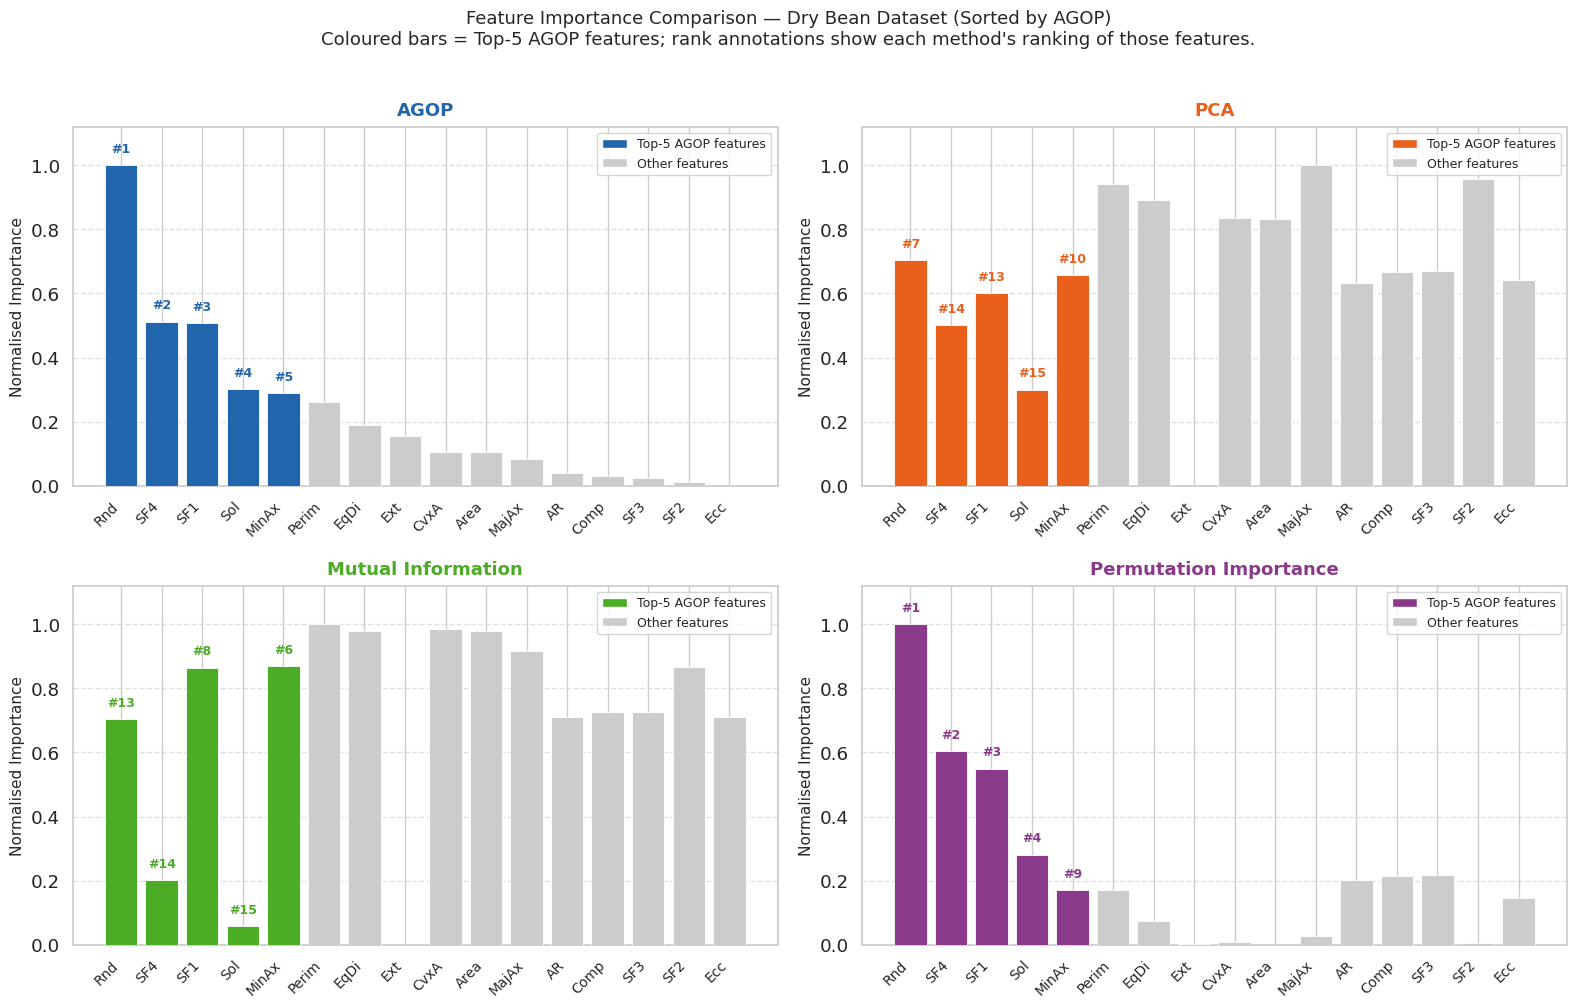

In [11]:
# Shorten feature names to avoid x-axis crowding.
SHORT_NAMES = {
    'Area':            'Area',
    'Perimeter':       'Perim',
    'MajorAxisLength': 'MajAx',
    'MinorAxisLength': 'MinAx',
    'AspectRatio':     'AR',
    'Eccentricity':    'Ecc',
    'ConvexArea':      'CvxA',
    'EquivDiameter':   'EqDi',
    'Extent':          'Ext',
    'Solidity':        'Sol',
    'Roundness':       'Rnd',
    'Compactness':     'Comp',
    'ShapeFactor1':    'SF1',
    'ShapeFactor2':    'SF2',
    'ShapeFactor3':    'SF3',
    'ShapeFactor4':    'SF4',
}

# Feature order (all 16, sorted by AGOP descending).
feature_order  = df_importance.index.tolist()
x_labels       = [SHORT_NAMES[f] for f in feature_order]
top5_agop      = set(df_importance['AGOP'].nlargest(5).index)

METHOD_COLORS = {
    'AGOP':                   '#2166AC',  # deep blue
    'PCA':                    '#E8601C',  # orange
    'Mutual Information':     '#4DAC26',  # green
    'Permutation Importance': '#8B3A8B',  # purple
}
GREY = '#CCCCCC'

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
axes_flat = axes.flatten()

for ax, method in zip(axes_flat, methods):
    values = df_importance[method].values
    accent = METHOD_COLORS[method]

    # Bar colours: accent for top-5 AGOP features, grey otherwise.
    bar_colors = [
        accent if feat in top5_agop else GREY
        for feat in feature_order
    ]

    bars = ax.bar(
        range(len(feature_order)), values,
        color=bar_colors, edgecolor='white', linewidth=0.6, zorder=3
    )

    ax.set_xticks(range(len(feature_order)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Normalised Importance', fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.set_title(method, fontsize=13, fontweight='bold', color=accent, pad=8)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
    ax.set_axisbelow(True)

    # Annotate the rank of the AGOP-top-5 features in THIS method's ranking.
    method_rank = df_importance[method].rank(ascending=False).astype(int)
    for bar_idx, feat in enumerate(feature_order):
        if feat in top5_agop:
            rank = method_rank[feat]
            ax.text(
                bar_idx, values[bar_idx] + 0.03,
                f'#{rank}', ha='center', va='bottom',
                fontsize=9, color=accent, fontweight='bold'
            )

    # Legend patches.
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=accent, label='Top-5 AGOP features'),
        Patch(facecolor=GREY,   label='Other features'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.8)

fig.suptitle(
    'Feature Importance Comparison — Dry Bean Dataset (Sorted by AGOP)\n'
    'Coloured bars = Top-5 AGOP features; rank annotations show each method\'s ranking of those features.',
    fontsize=13, y=1.01
)
plt.tight_layout()

out_path = os.path.join(RESULT_DIR, 'interpretability_comparison.png')
plt.savefig(out_path, dpi=200, bbox_inches='tight')
print(f'Figure saved → {out_path}')
plt.show()

## 10. Supplementary: Rank-Correlation Heatmap

Heatmap saved → /home/wuxinzhe76/COMP9417-PR/results/interpretability_rank_correlation.png


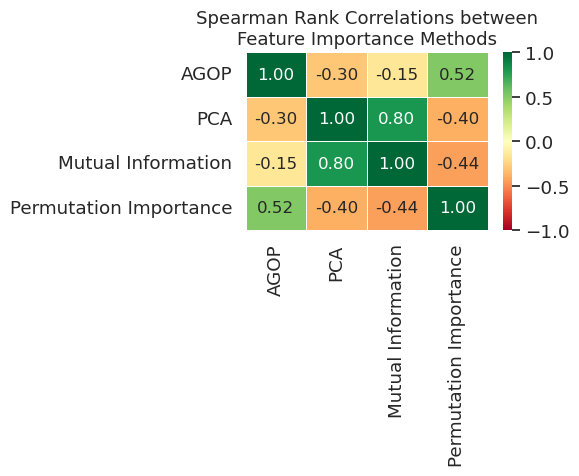

In [12]:
fig2, ax2 = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix.astype(float),
    annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, linewidths=0.5, ax=ax2,
    annot_kws={'size': 12}
)
ax2.set_title('Spearman Rank Correlations between\nFeature Importance Methods', fontsize=13)
plt.tight_layout()

out_path2 = os.path.join(RESULT_DIR, 'interpretability_rank_correlation.png')
plt.savefig(out_path2, dpi=200, bbox_inches='tight')
print(f'Heatmap saved → {out_path2}')
plt.show()

## 11. Save Importance Table to CSV

In [13]:
# Save raw (un-normalised) scores for reporting.
df_raw = pd.DataFrame({
    'Feature':               feature_order,
    'AGOP':                  [agop_scores[f] for f in feature_order],
    'PCA_PC1_loading':       [pca_scores[f]  for f in feature_order],
    'Mutual_Information':    [mi_scores[f]   for f in feature_order],
    'Permutation_Importance':[pi_scores[f]   for f in feature_order],
    'AGOP_rank':             [int(agop_scores.rank(ascending=False)[f]) for f in feature_order],
    'PCA_rank':              [int(pca_scores .rank(ascending=False)[f]) for f in feature_order],
    'MI_rank':               [int(mi_scores  .rank(ascending=False)[f]) for f in feature_order],
    'PI_rank':               [int(pi_scores  .rank(ascending=False)[f]) for f in feature_order],
})

csv_path = os.path.join(RESULT_DIR, 'interpretability_scores.csv')
df_raw.to_csv(csv_path, index=False)
print(f'Raw scores saved → {csv_path}')
print()
print(df_raw.to_string(index=False))

Raw scores saved → /home/wuxinzhe76/COMP9417-PR/results/interpretability_scores.csv

        Feature     AGOP  PCA_PC1_loading  Mutual_Information  Permutation_Importance  AGOP_rank  PCA_rank  MI_rank  PI_rank
      Roundness 1.000000         0.248594            0.796307                0.191003          1         7       13        1
   ShapeFactor4 0.539446         0.195462            0.365255                0.122806          2        14       14        2
   ShapeFactor1 0.534758         0.221515            0.934747                0.113184          3        13        8        3
       Solidity 0.342024         0.142697            0.241617                0.066985          4        15       15        4
MinorAxisLength 0.329744         0.236045            0.938823                0.047631          5        10        6        9
      Perimeter 0.304420         0.310826            1.050943                0.047888          6         3        1        8
  EquivDiameter 0.234784         0.29739

## 12. Analysis: Where Do Methods Agree and Diverge?

Run the cell below to auto-generate a structured textual summary suitable for the report's Discussion section.

In [14]:
TOP_K = 5

ranks = {
    'AGOP':                  agop_scores.rank(ascending=False).astype(int),
    'PCA':                   pca_scores .rank(ascending=False).astype(int),
    'Mutual Information':    mi_scores  .rank(ascending=False).astype(int),
    'Permutation Importance':pi_scores  .rank(ascending=False).astype(int),
}

top_sets = {m: set(s.nsmallest(TOP_K).index) for m, s in ranks.items()}

print(f'=== Top-{TOP_K} features per method ===')
for m, s in top_sets.items():
    print(f'  {m:30s}: {sorted(s)}')

print(f'\n=== Agreement analysis ===')
# Features in ALL four top-K sets.
all_agree = set.intersection(*top_sets.values())
print(f'  In ALL methods\' top-{TOP_K}: {sorted(all_agree)}')

# Features in AGOP top-K but NOT in PCA top-K (AGOP-unique, label-driven).
agop_not_pca = top_sets['AGOP'] - top_sets['PCA']
print(f'  In AGOP top-{TOP_K} but NOT PCA top-{TOP_K} (label-driven, not variance-driven): {sorted(agop_not_pca)}')

# Features in PCA top-K but NOT in AGOP top-K (variance-driven, not label-driven).
pca_not_agop = top_sets['PCA'] - top_sets['AGOP']
print(f'  In PCA top-{TOP_K} but NOT AGOP top-{TOP_K} (variance-driven, label-uninformative): {sorted(pca_not_agop)}')

print(f'\n=== Spearman ρ summary ===')
compare_scores = {
    'PCA':                   pca_scores,
    'Mutual Information':    mi_scores,
    'Permutation Importance':pi_scores,
}
for m, s in compare_scores.items():
    rho, pval = spearmanr(agop_scores, s)
    print(f'  AGOP vs {m:30s}: ρ = {rho:.3f}  (p={pval:.3e})')

=== Top-5 features per method ===
  AGOP                          : ['MinorAxisLength', 'Roundness', 'ShapeFactor1', 'ShapeFactor4', 'Solidity']
  PCA                           : ['ConvexArea', 'EquivDiameter', 'MajorAxisLength', 'Perimeter', 'ShapeFactor2']
  Mutual Information            : ['Area', 'ConvexArea', 'EquivDiameter', 'MajorAxisLength', 'Perimeter']
  Permutation Importance        : ['Roundness', 'ShapeFactor1', 'ShapeFactor3', 'ShapeFactor4', 'Solidity']

=== Agreement analysis ===
  In ALL methods' top-5: []
  In AGOP top-5 but NOT PCA top-5 (label-driven, not variance-driven): ['MinorAxisLength', 'Roundness', 'ShapeFactor1', 'ShapeFactor4', 'Solidity']
  In PCA top-5 but NOT AGOP top-5 (variance-driven, label-uninformative): ['ConvexArea', 'EquivDiameter', 'MajorAxisLength', 'Perimeter', 'ShapeFactor2']

=== Spearman ρ summary ===
  AGOP vs PCA                           : ρ = -0.303  (p=2.541e-01)
  AGOP vs Mutual Information            : ρ = -0.153  (p=5.717e-01)
  AGO